In [1]:
import pandas as pd

In [5]:
#importing packages
from pandas import read_csv
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("E:\\sweetlin-official\\Win 2022 -23\\Data Analytics\\Lab\dataset\\pima-indians-diabetes.csv",header=None)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [14]:
#loading dataset
def load_dataset(fname):
    data=read_csv(fname,header=None)
    dataset=data.values
    X=dataset[:,:-1]
    y=dataset[:,-1]
    return X,y

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
l=[10,11,12,13,14]

In [7]:
l[2] #indexing

12

In [9]:
l[1:4] #slicing

[11, 12, 13]

In [10]:
l

[10, 11, 12, 13, 14]

In [11]:
l[-1]

14

In [13]:
l[:-1]

[10, 11, 12, 13]

In [15]:
#Train Test split
X,y=load_dataset('E:\\sweetlin-official\\Win 2022 -23\\Data Analytics\\Lab\dataset\\pima-indians-diabetes.csv')
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=1)
print('Train',X_train.shape,y_train.shape)
print('Test',X_test.shape,y_test.shape)

Train (514, 8) (514,)
Test (254, 8) (254,)


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [17]:
#Create a decision tree classifier object
dt=DecisionTreeClassifier(criterion='entropy')

In [18]:
#Train the decision tree
dt=dt.fit(X_train, y_train)

In [19]:
#predict the response for the test data
yhat=dt.predict(X_test)

In [20]:
#Evaluate the model
accuracy=accuracy_score(y_test,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 72.83


In [21]:
from sklearn.tree import plot_tree,export_text
import matplotlib.pyplot as plt

[Text(1729.8, 978.48, 'insulin <= 127.5\nentropy = 0.927\nsamples = 514\nvalue = [338, 176]\nclass = 0'),
 Text(669.5999999999999, 761.0400000000001, 'skinthick <= 22.5\nentropy = 0.722\nsamples = 325\nvalue = [260, 65]\nclass = 0'),
 Text(446.4, 543.6, 'entropy = 0.0\nsamples = 67\nvalue = [67, 0]\nclass = 0'),
 Text(892.8, 543.6, 'bp <= 26.45\nentropy = 0.814\nsamples = 258\nvalue = [193, 65]\nclass = 0'),
 Text(446.4, 326.1600000000001, 'bp <= 9.1\nentropy = 0.28\nsamples = 62\nvalue = [59, 3]\nclass = 0'),
 Text(223.2, 108.72000000000003, '\n  (...)  \n'),
 Text(669.5999999999999, 108.72000000000003, '\n  (...)  \n'),
 Text(1339.1999999999998, 326.1600000000001, 'pedigree <= 0.634\nentropy = 0.9\nsamples = 196\nvalue = [134, 62]\nclass = 0'),
 Text(1116.0, 108.72000000000003, '\n  (...)  \n'),
 Text(1562.3999999999999, 108.72000000000003, '\n  (...)  \n'),
 Text(2790.0, 761.0400000000001, 'bp <= 29.85\nentropy = 0.978\nsamples = 189\nvalue = [78, 111]\nclass = 1'),
 Text(2008.8, 54

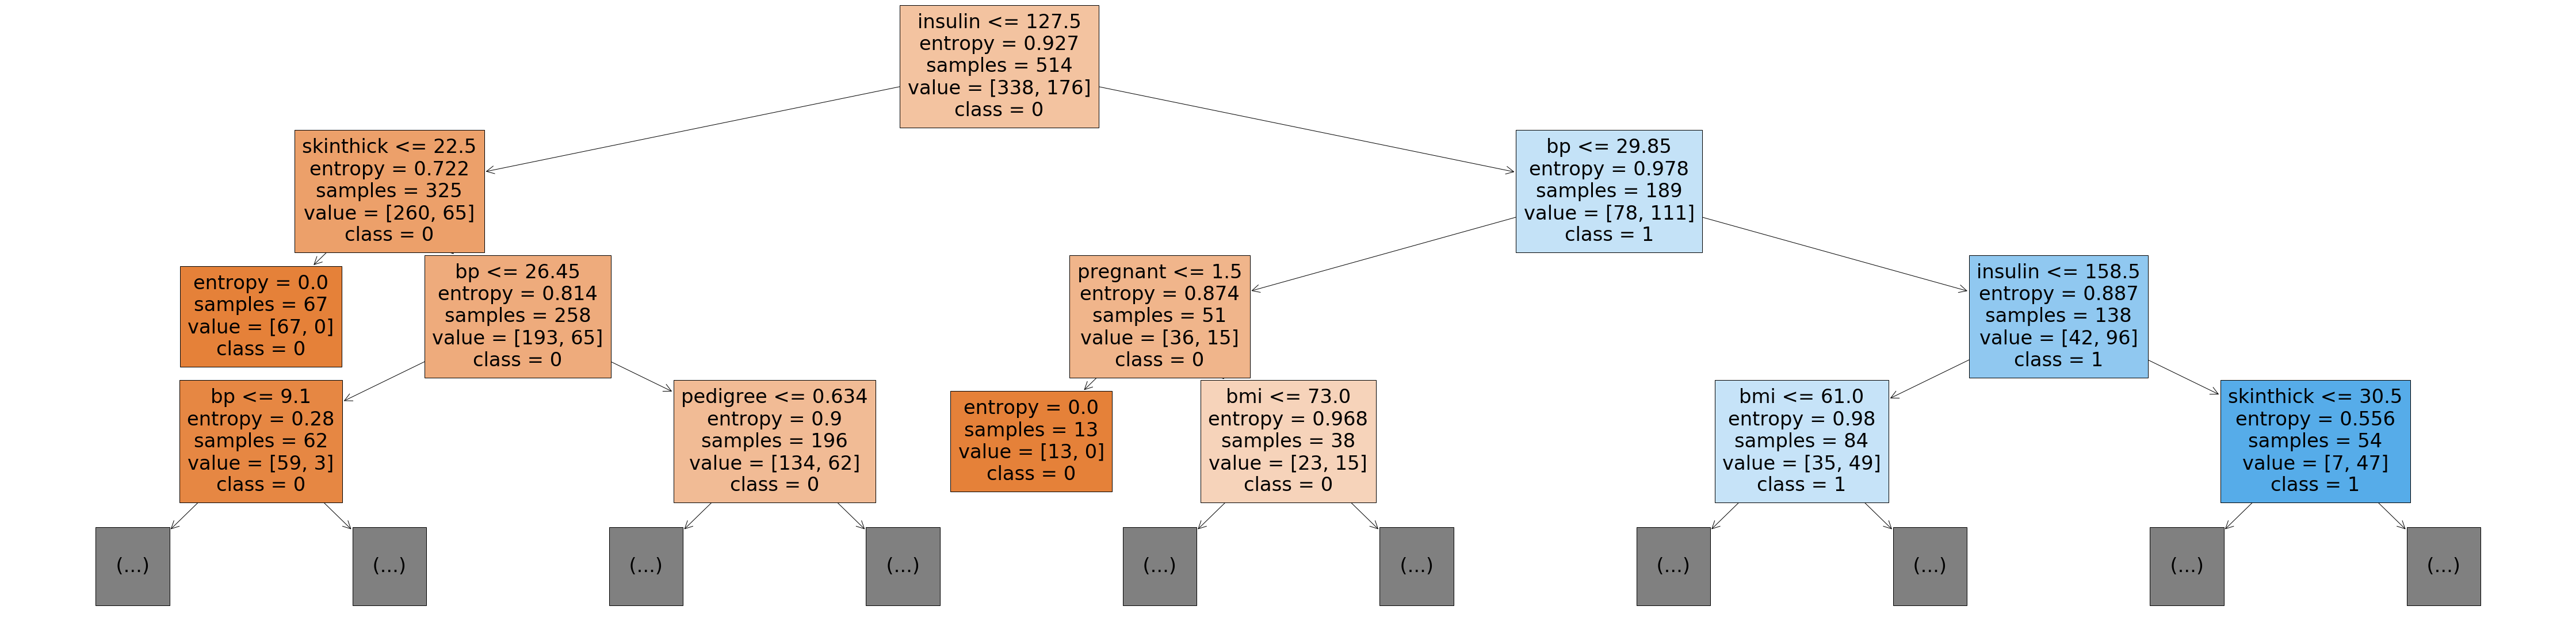

In [22]:
plt.figure(figsize=(80,20))
plot_tree(dt,feature_names=['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree','skinthick'],class_names=['0','1'],max_depth=3,filled=True)

In [23]:
#hyperparameter tuning
dt.tree_.max_depth

17

In [24]:
for max_d in range(1,10):
    dt=DecisionTreeClassifier(max_depth=max_d,random_state=2)
    dt.fit(X_train,y_train)
    print('The Training Accuracy for max_depth {} is:'.format(max_d), dt.score(X_train, y_train))
    print('The Validation Accuracy for max_depth {} is:'.format(max_d), dt.score(X_test,y_test))
    print('')

The Training Accuracy for max_depth 1 is: 0.7217898832684825
The Validation Accuracy for max_depth 1 is: 0.7637795275590551

The Training Accuracy for max_depth 2 is: 0.7626459143968871
The Validation Accuracy for max_depth 2 is: 0.7874015748031497

The Training Accuracy for max_depth 3 is: 0.7626459143968871
The Validation Accuracy for max_depth 3 is: 0.7874015748031497

The Training Accuracy for max_depth 4 is: 0.77431906614786
The Validation Accuracy for max_depth 4 is: 0.7125984251968503

The Training Accuracy for max_depth 5 is: 0.8482490272373541
The Validation Accuracy for max_depth 5 is: 0.7322834645669292

The Training Accuracy for max_depth 6 is: 0.877431906614786
The Validation Accuracy for max_depth 6 is: 0.7322834645669292

The Training Accuracy for max_depth 7 is: 0.9105058365758755
The Validation Accuracy for max_depth 7 is: 0.7244094488188977

The Training Accuracy for max_depth 8 is: 0.9455252918287937
The Validation Accuracy for max_depth 8 is: 0.7047244094488189

The

It is observed that the accuracy is high for max_depth=3